# Comparatif des Mipmaps générés par différentes méthodes
Ce notebook permet de générer et de mettre côte à côte les niveaux de mipmaps obtenus par trois filtres : FGP-TV, Moyenne et Médiane.

In [2]:
import sys
sys.path.append('../python')
import cv2
import matplotlib.pyplot as plt
from generate_mimap import filtre, moy, med

# --- PARAMÈTRES ---
image_path = '../image/chat.jpg'

lambda_val = 0.05 # Pour FGP-TV
iterations = 10   # Pour FGP-TV
maskSize = 3      # Pour Moyenne et Médiane (Chiffre impair recommandé : 3, 5, 7...)
padMode = 1       # 0 = Remplir de zéros | 1 = Répéter le bord de l'image

# Lecture de l'image en niveaux de gris
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Image non trouvée au chemin spécifié : {image_path}")
    
print(f"Image originale chargée. Taille: {img.shape}")


Image originale chargée. Taille: (225, 225)


In [3]:
# Génération des niveaux pour chaque méthode
print("Génération via filtre FGP-TV...")
levels_filtre = filtre(img, lambda_val, iterations)

print("Génération via filtre Moyenne...")
levels_moy = moy(img, maskSize, padMode=padMode)

print("Génération via filtre Médiane...")
levels_med = med(img, maskSize, padMode=padMode)

print("Toutes les pyramides mipmaps ont été générées.")

Génération via filtre FGP-TV...
Niveau généré : (112, 112)
Niveau généré : (56, 56)
Niveau généré : (28, 28)
Niveau généré : (14, 14)
Niveau généré : (7, 7)
Niveau généré : (3, 3)
Niveau généré : (1, 1)
Génération via filtre Moyenne...
Niveau généré : (112, 112)
Niveau généré : (56, 56)
Niveau généré : (28, 28)
Niveau généré : (14, 14)
Niveau généré : (7, 7)
Niveau généré : (3, 3)
Niveau généré : (1, 1)
Génération via filtre Médiane...
Niveau généré : (112, 112)
Niveau généré : (56, 56)
Niveau généré : (28, 28)
Niveau généré : (14, 14)
Niveau généré : (7, 7)
Niveau généré : (3, 3)
Niveau généré : (1, 1)
Toutes les pyramides mipmaps ont été générées.


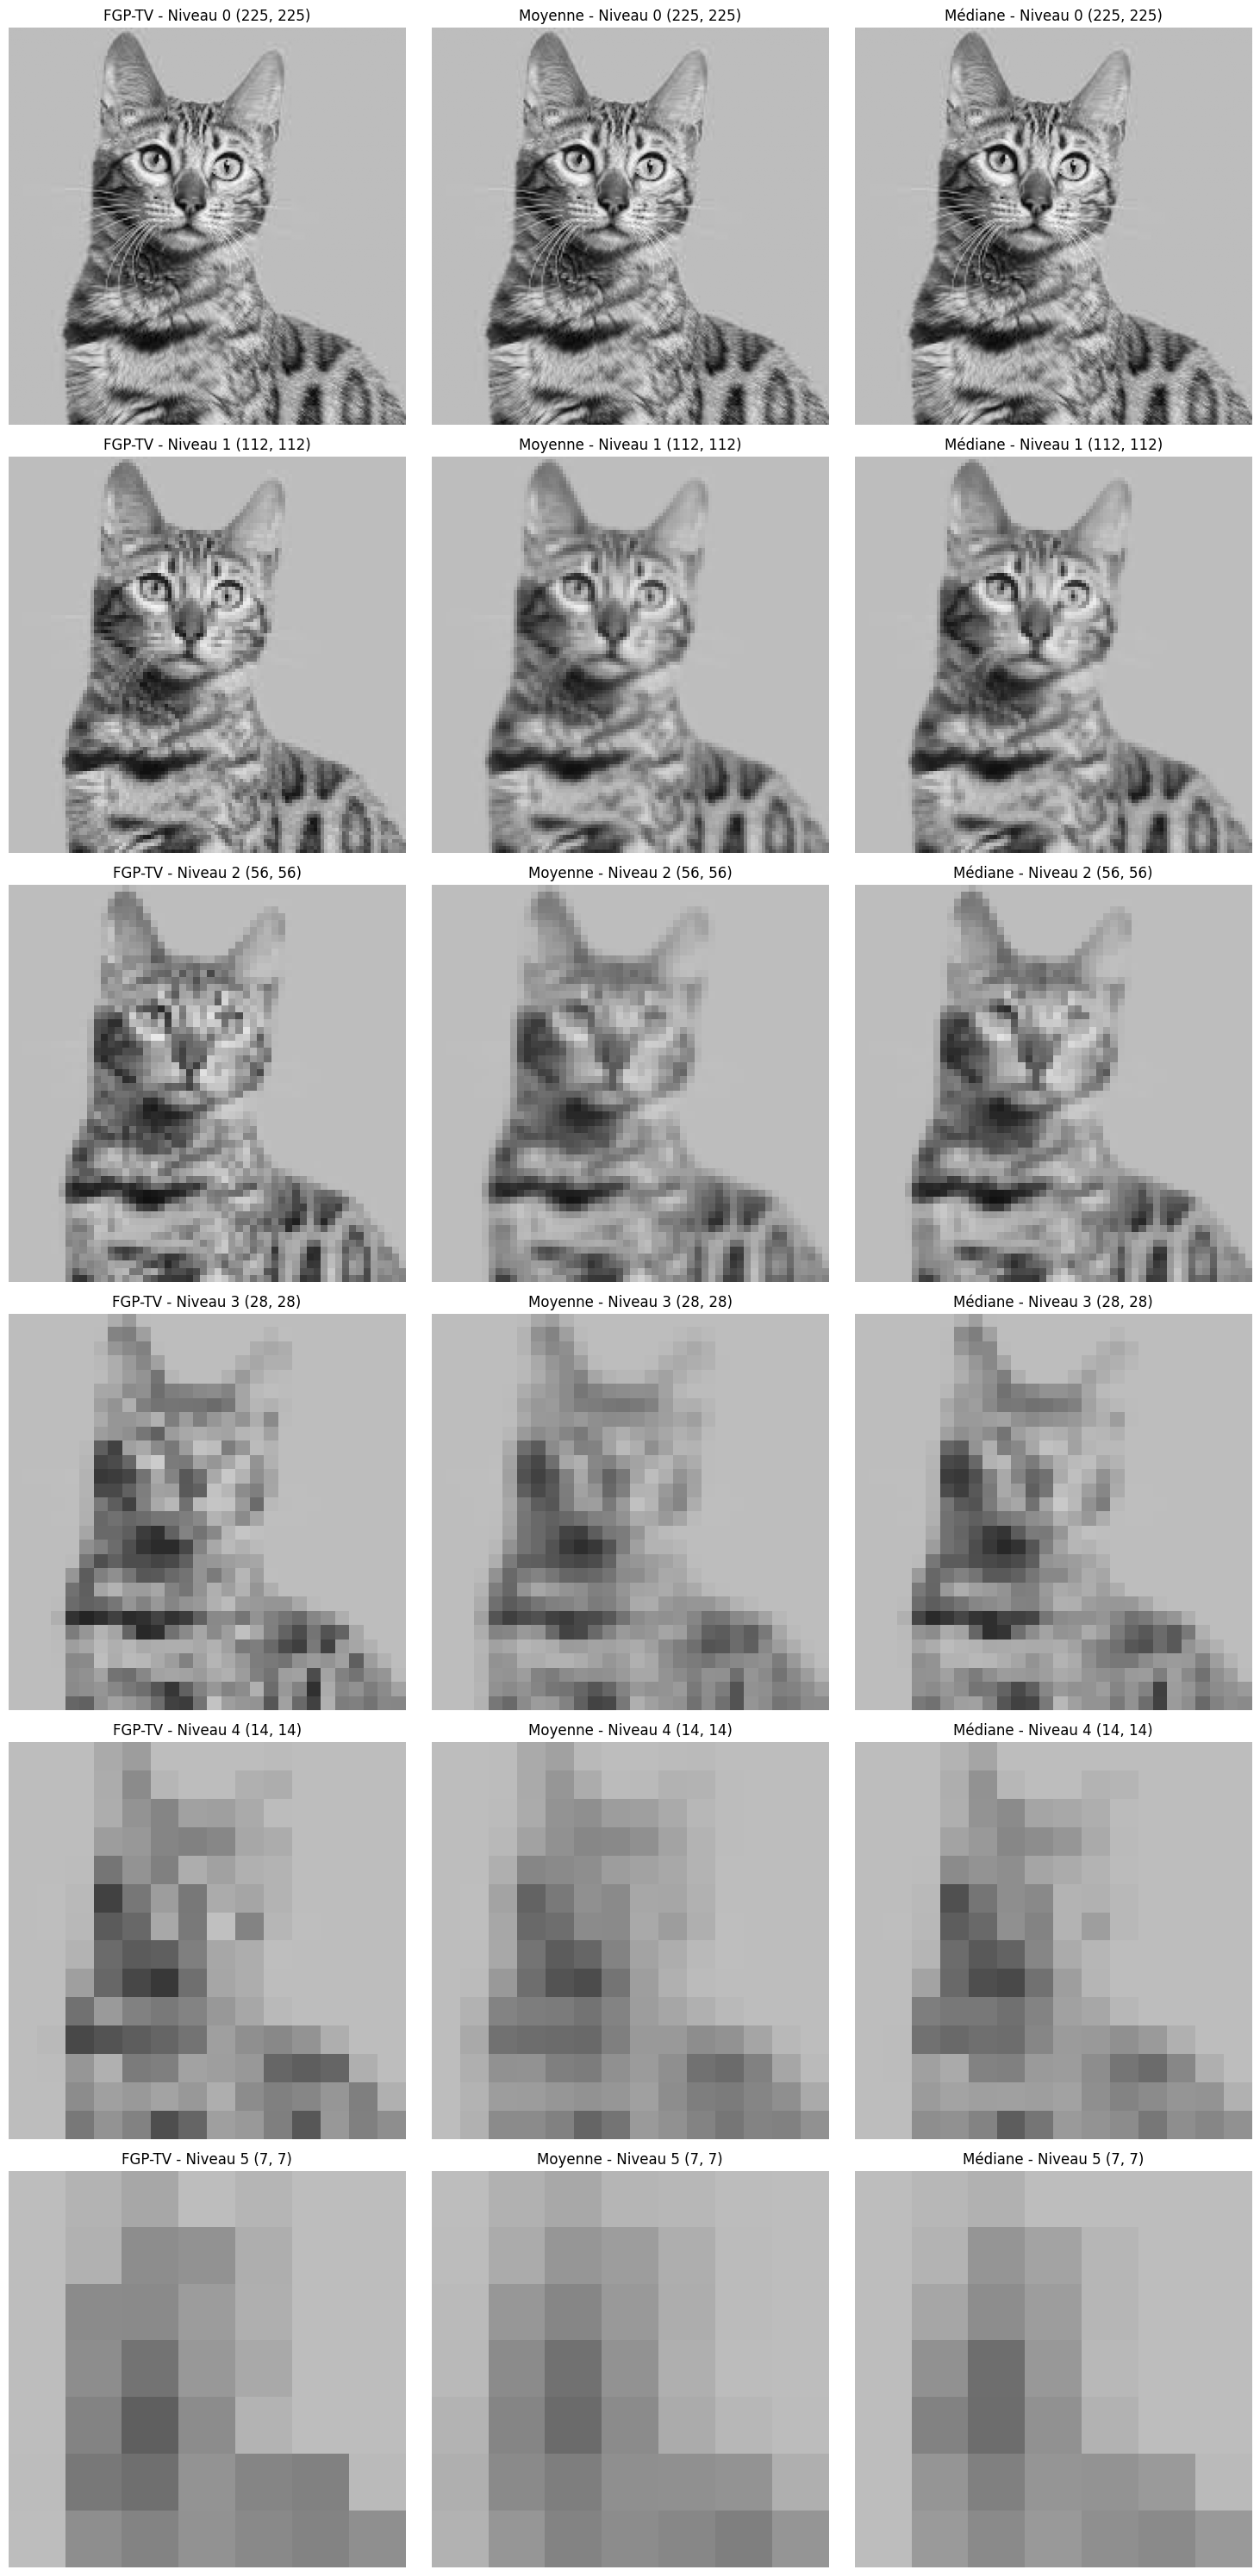

In [4]:
# ----- AFFICHAGE DES RÉSULTATS -----

# On prend le nombre minimum de niveaux pour être sûr, et on limite l'affichage aux 5 ou 6 premiers niveaux
# car les niveaux suivants (1x1, 2x2...) sont trop petits pour être visuellement intéressants.
num_levels = min(len(levels_filtre), len(levels_moy), len(levels_med))
display_levels = min(num_levels, 6) # Modifiez cette valeur pour afficher plus/moins de niveaux

fig, axes = plt.subplots(display_levels, 3, figsize=(15, 5 * display_levels))

# Gestion du cas où on n'affiche qu'un seul niveau (axes devient 1D)
if display_levels == 1:
    axes = [axes]

for i in range(display_levels):
    # Colonne 1 : FGP-TV
    axes[i][0].imshow(levels_filtre[i], cmap='gray', vmin=0, vmax=255)
    axes[i][0].set_title(f'FGP-TV - Niveau {i} {levels_filtre[i].shape}')
    axes[i][0].axis('off')
    
    # Colonne 2 : Moyenne
    axes[i][1].imshow(levels_moy[i], cmap='gray', vmin=0, vmax=255)
    axes[i][1].set_title(f'Moyenne - Niveau {i} {levels_moy[i].shape}')
    axes[i][1].axis('off')
    
    # Colonne 3 : Médiane
    axes[i][2].imshow(levels_med[i], cmap='gray', vmin=0, vmax=255)
    axes[i][2].set_title(f'Médiane - Niveau {i} {levels_med[i].shape}')
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()